# NYC Airbnb Price Prediction
### Neha Mahesh - Final Project

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

In [59]:
df = pd.read_csv('AB_NYC_2019.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [61]:
print(f"Columns: {list(df.columns)}\n")
print(df.dtypes)

Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


## Exploratory Data Analysis

In [10]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


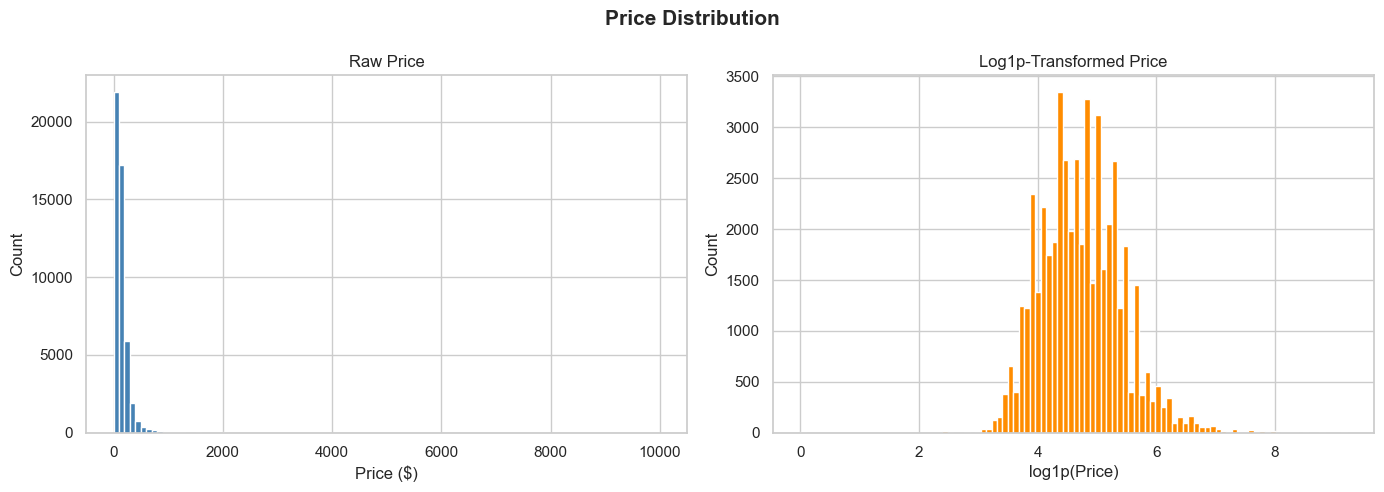

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution', fontsize=15, fontweight='bold')

axes[0].hist(df['price'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Price')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price'].dropna()), bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('Log1p-Transformed Price')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plot_01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

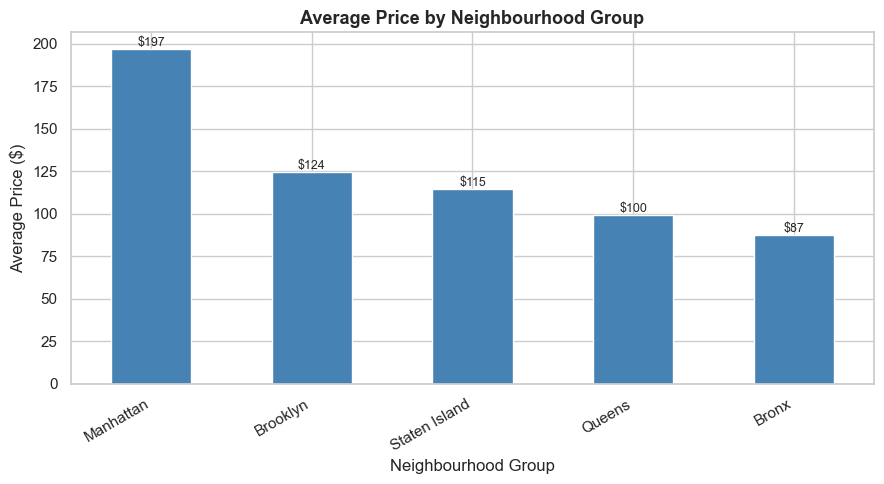

In [67]:
avg_by_group = (
    df.groupby('neighbourhood_group')['price']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
avg_by_group.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Price by Neighbourhood Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Neighbourhood Group')
ax.set_ylabel('Average Price ($)')
ax.set_xticklabels(avg_by_group.index, rotation=30, ha='right')
for bar in ax.patches:
    ax.annotate(f'${bar.get_height():.0f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot_02_avg_price_by_neighbourhood_group.png', dpi=150, bbox_inches='tight')
plt.show()

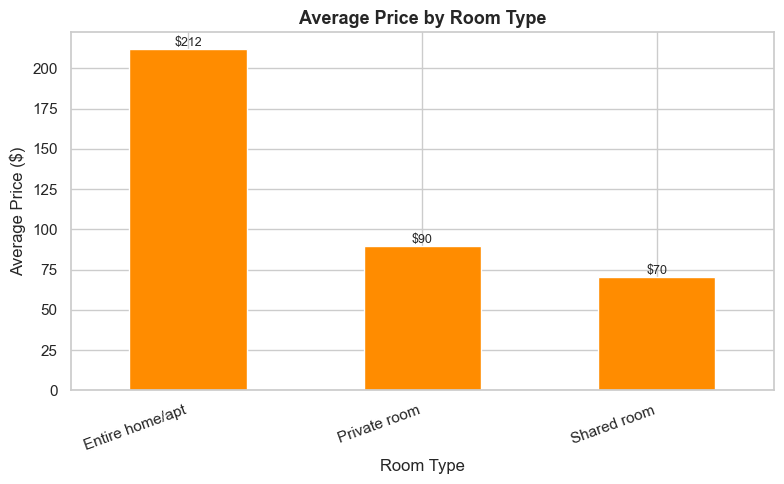

In [69]:
avg_by_room = (
    df.groupby('room_type')['price']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
avg_by_room.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Average Price by Room Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Room Type')
ax.set_ylabel('Average Price ($)')
ax.set_xticklabels(avg_by_room.index, rotation=20, ha='right')
for bar in ax.patches:
    ax.annotate(f'${bar.get_height():.0f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot_03_avg_price_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

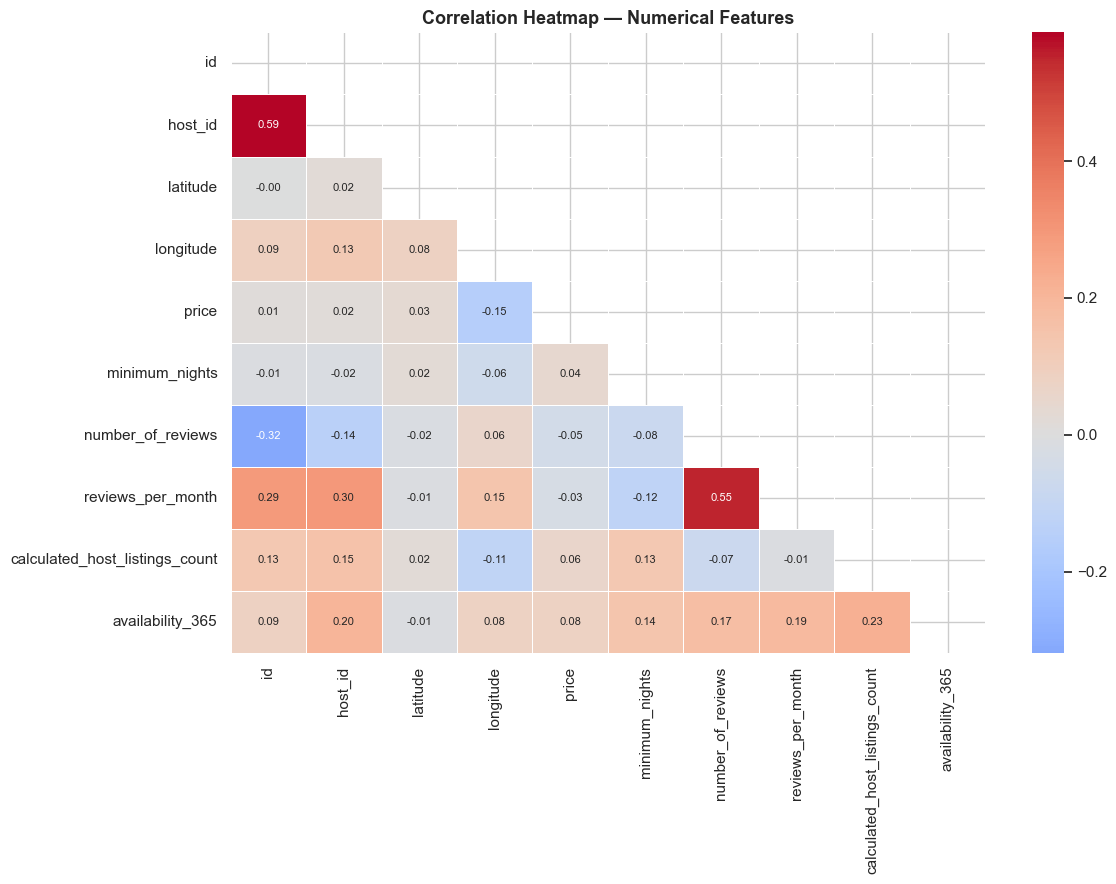

In [71]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing

In [74]:
data = df.copy()

# Drop irrelevant columns
drop_cols = ['id', 'host_id', 'name', 'host_name', 'last_review', 'neighbourhood']
data.drop(columns=drop_cols, inplace=True)

# Fill missing reviews_per_month with 0
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)

# Remove listings with price == 0
before = len(data)
data = data[data['price'] > 0]
print(f"Removed {before - len(data)} listings with price == 0  ({len(data)} remaining)")

# Cap price at 99th percentile
p99 = data['price'].quantile(0.99)
before_cap = (data['price'] > p99).sum()
data['price'] = data['price'].clip(upper=p99)
print(f"Capped {before_cap} listings at 99th-percentile (${p99:.2f})")

# Log1p-transform price
data['price'] = np.log1p(data['price'])
print("Applied log1p to price")

# One-hot encode categoricals
data = pd.get_dummies(data, columns=['room_type', 'neighbourhood_group'], drop_first=False)
print(f"After OHE — shape: {data.shape}")

data.head()

Removed 11 listings with price == 0  (48884 remaining)
Capped 474 listings at 99th-percentile ($799.00)
Applied log1p to price
After OHE — shape: (48884, 16)


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,40.64749,-73.97237,5.010635,1,9,0.21,6,365,False,True,False,False,True,False,False,False
1,40.75362,-73.98377,5.420535,1,45,0.38,2,355,True,False,False,False,False,True,False,False
2,40.80902,-73.94190,5.017280,3,0,0.00,1,365,False,True,False,False,False,True,False,False
3,40.68514,-73.95976,4.499810,1,270,4.64,1,194,True,False,False,False,True,False,False,False
4,40.79851,-73.94399,4.394449,10,9,0.10,1,0,True,False,False,False,False,True,False,False


In [22]:
# Standardize numerical features
num_features = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'latitude', 'longitude'
]
scaler = StandardScaler()
data[num_features] = scaler.fit_transform(data[num_features])

# Train / test split
X = data.drop(columns=['price'])
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({X.shape[1]}): {list(X.columns)}")

Train: (39107, 15)  |  Test: (9777, 15)
Features (15): ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']


## Train Models

In [24]:
models = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':      DecisionTreeRegressor(max_depth=10, random_state=SEED),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=SEED),
}

trained = {}
for name, model in models.items():
    print(f"Training {name} ...", end=' ', flush=True)
    model.fit(X_train, y_train)
    trained[name] = model
    print("done")

Training Linear Regression ... done
Training Decision Tree ... done
Training Random Forest ... done
Training Gradient Boosting ... done


## Evaluate Models
MAE and RMSE are computed in **dollar terms** (inverse log1p applied). R² is in log space.

In [87]:
results = {}
for name, model in trained.items():
    y_pred_log = model.predict(X_test)

    y_test_dollars = np.expm1(y_test)
    y_pred_dollars = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_test_dollars, y_pred_dollars)
    rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
    r2   = r2_score(y_test, y_pred_log)

    results[name] = {'MAE ($)': mae, 'RMSE ($)': rmse, 'R² Score': r2, 'y_pred_log': y_pred_log}

# comparison table
results_df = pd.DataFrame(
    {name: {k: v for k, v in res.items() if k != 'y_pred_log'} for name, res in results.items()}
).T.round(4)

results_df.style.highlight_max(subset=['R² Score'], color='lightgreen') \
               .highlight_min(subset=['MAE ($)', 'RMSE ($)'], color='lightgreen') \
               .format({'MAE ($)': '${:.2f}', 'RMSE ($)': '${:.2f}', 'R² Score': '{:.4f}'})

,MAE ($),RMSE ($),R² Score
Linear Regression,$54.65,$104.16,0.4969
Decision Tree,$51.45,$99.73,0.5585
Random Forest,$48.63,$93.77,0.6064
Gradient Boosting,$50.36,$98.58,0.5903


## Visualize Results

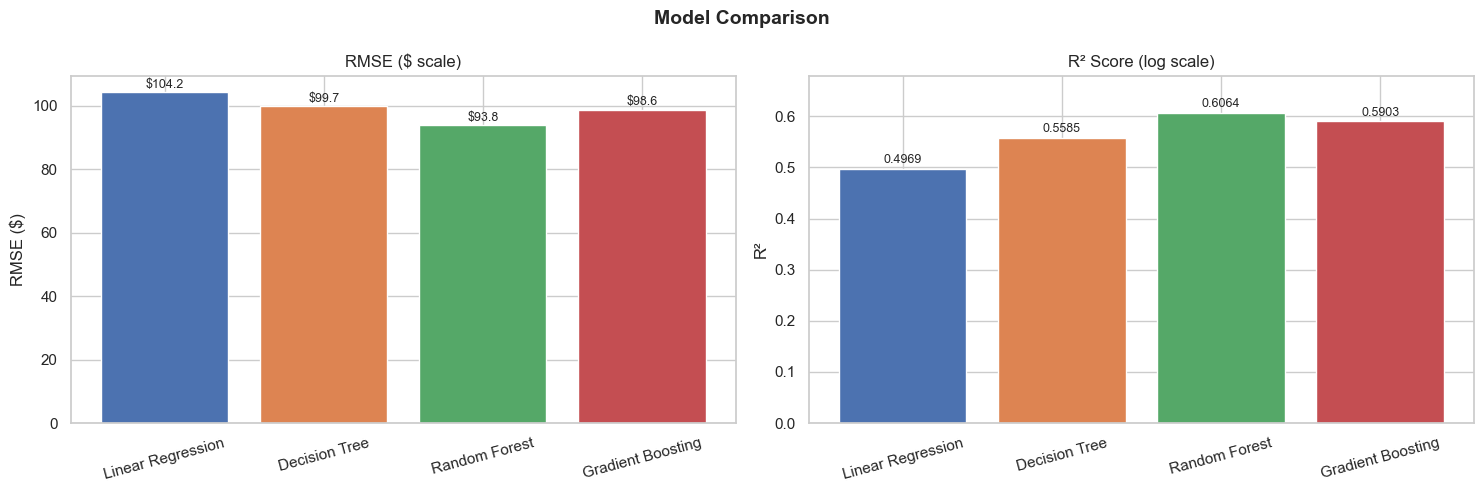

In [32]:
model_names = list(results.keys())
rmse_vals   = [results[m]['RMSE ($)'] for m in model_names]
r2_vals     = [results[m]['R² Score'] for m in model_names]
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# RMSE bar chart
bars = axes[0].bar(model_names, rmse_vals, color=colors, edgecolor='white')
axes[0].set_title('RMSE ($ scale)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'${val:.1f}', ha='center', va='bottom', fontsize=9)

# R² bar chart
bars = axes[1].bar(model_names, r2_vals, color=colors, edgecolor='white')
axes[1].set_title('R² Score (log scale)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, max(r2_vals) * 1.12)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Actual vs Predicted

Best model by R²: Random Forest


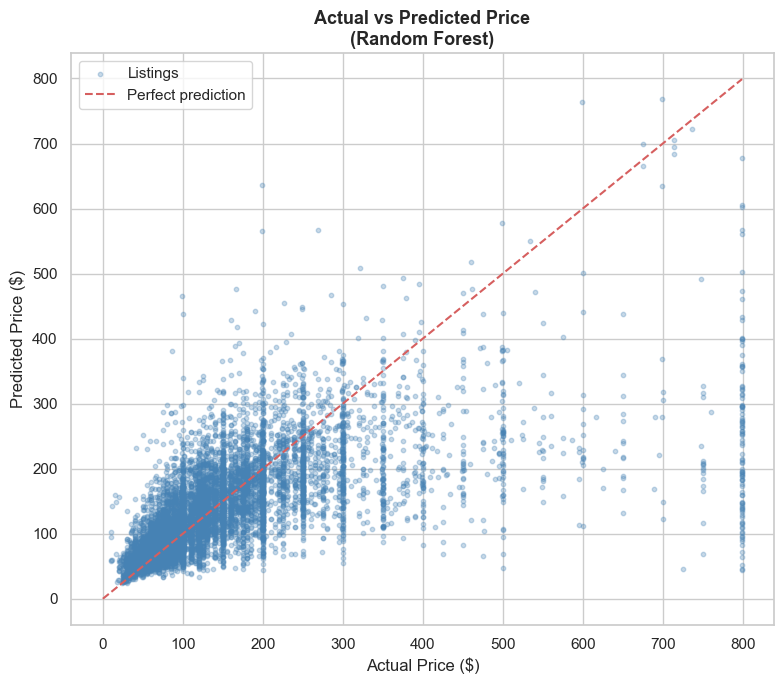

In [34]:
best_model_name = max(results, key=lambda m: results[m]['R² Score'])
print(f"Best model by R²: {best_model_name}")

y_pred_best    = results[best_model_name]['y_pred_log']
actual_dollars = np.expm1(y_test)
pred_dollars   = np.expm1(y_pred_best)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(actual_dollars, pred_dollars, alpha=0.3, s=10, color='steelblue', label='Listings')
max_val = max(actual_dollars.max(), pred_dollars.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title(f'Actual vs Predicted Price\n({best_model_name})', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_06_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance
Top 10 features for Random Forest and Gradient Boosting.

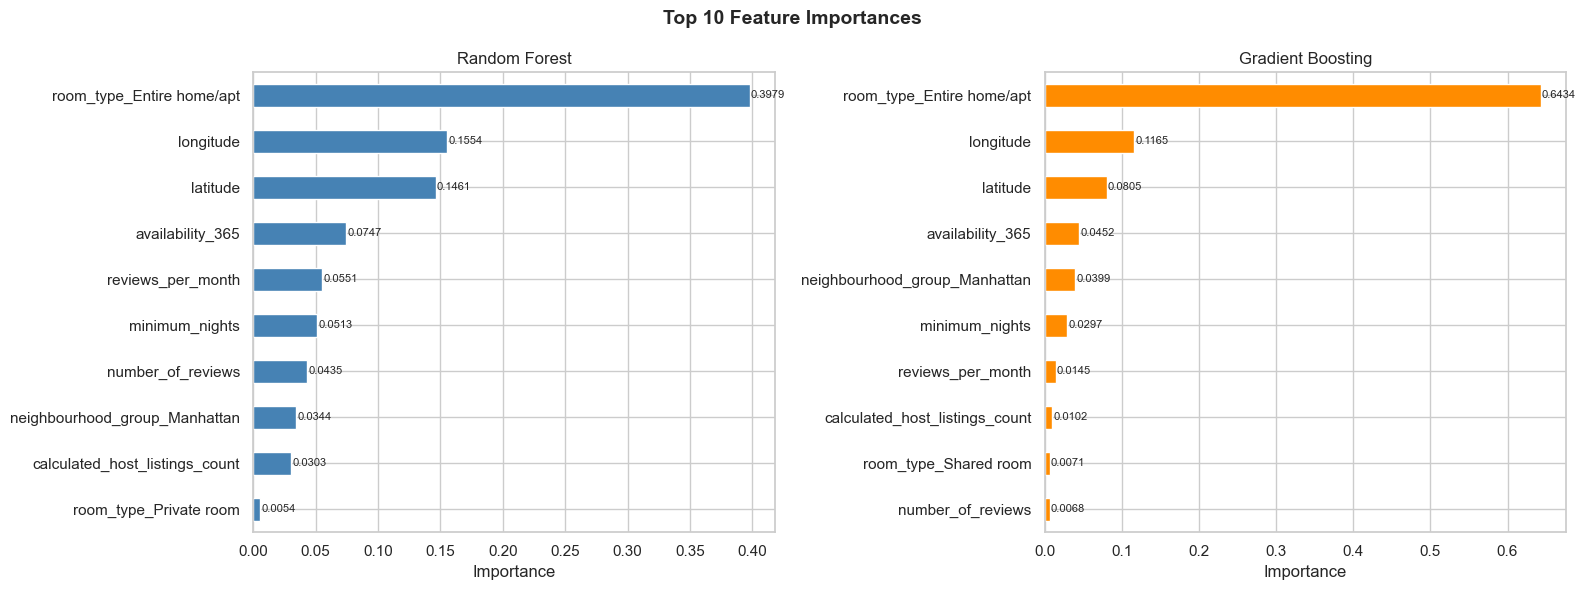

In [36]:
importance_models = {
    'Random Forest':     (trained['Random Forest'],    'steelblue'),
    'Gradient Boosting': (trained['Gradient Boosting'], 'darkorange'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Feature Importances', fontsize=14, fontweight='bold')

for ax, (name, (model, color)) in zip(axes, importance_models.items()):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top10 = importances.nlargest(10).sort_values()
    top10.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(name)
    ax.set_xlabel('Importance')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##  Metrics Summary

In [85]:
# Print full metrics table
print("Model Performance Summary")
print("=" * 50)
print(results_df.to_string())

Model Performance Summary
                   MAE ($)  RMSE ($)  R² Score
Linear Regression  54.6517  104.1612    0.4969
Decision Tree      51.4476   99.7260    0.5585
Random Forest      48.6261   93.7678    0.6064
Gradient Boosting  50.3595   98.5825    0.5903


## Cross Validation

In [48]:
print("5-Fold Cross Validation R2 Scores\n")

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}")
    print(f"  Scores: {cv_scores.round(4)}")
    print(f"  Mean R2: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
    print()

5-Fold Cross Validation R2 Scores

Linear Regression
  Scores: [0.515  0.5148 0.5186 0.5097 0.5092]
  Mean R2: 0.5135  |  Std: 0.0036

Decision Tree
  Scores: [0.5706 0.554  0.5659 0.5625 0.5472]
  Mean R2: 0.5600  |  Std: 0.0084

Random Forest
  Scores: [0.6279 0.6221 0.6245 0.6189 0.6129]
  Mean R2: 0.6213  |  Std: 0.0051

Gradient Boosting
  Scores: [0.6114 0.6037 0.6139 0.5992 0.6015]
  Mean R2: 0.6059  |  Std: 0.0057



## Residual Plots

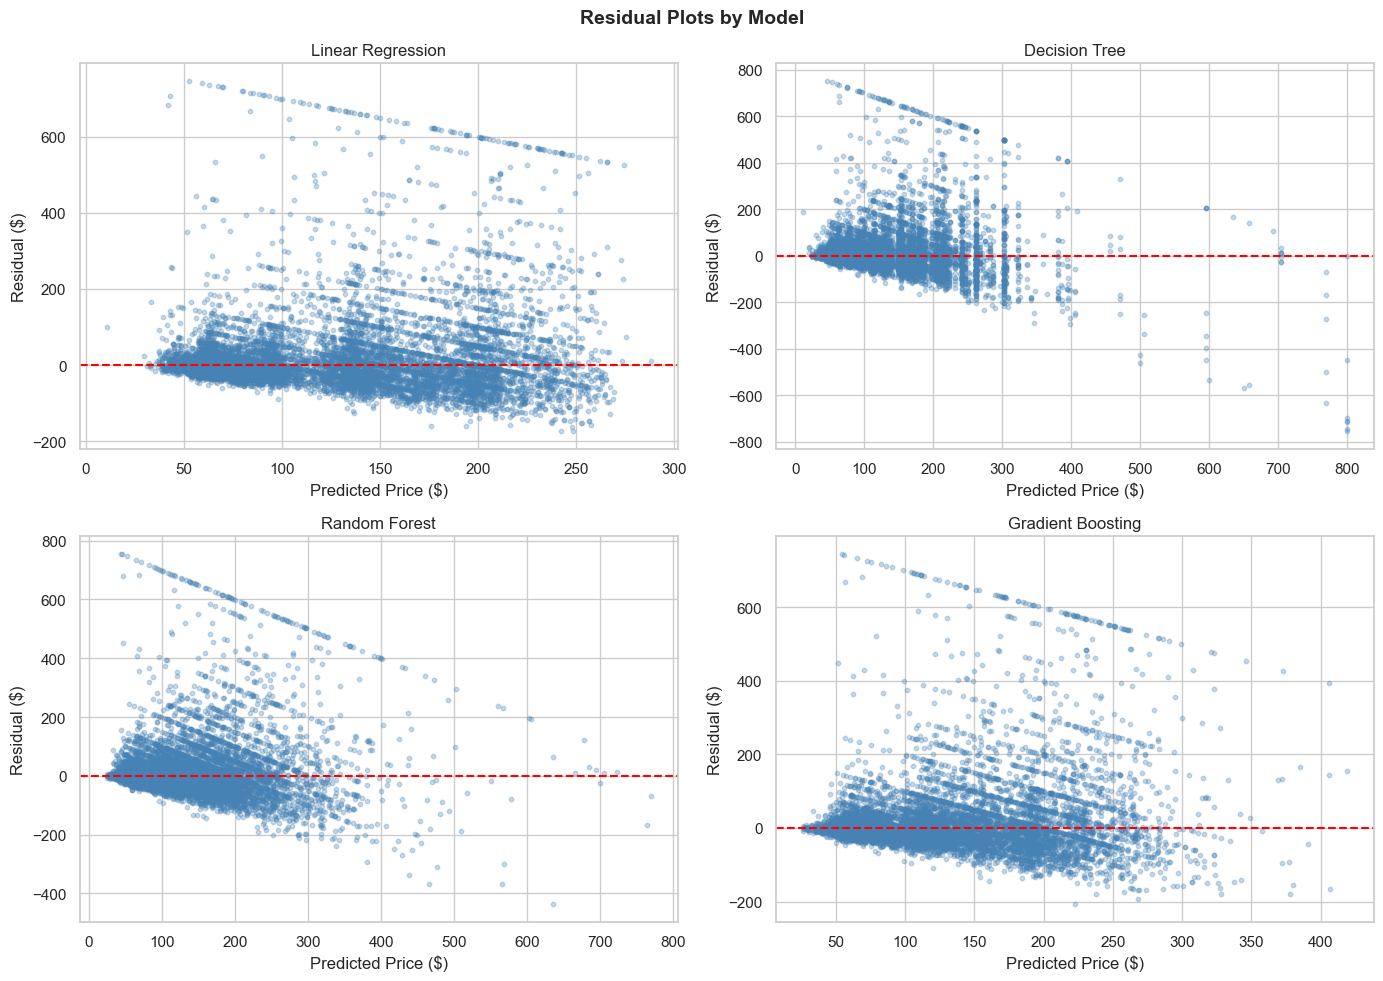

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Residual Plots by Model", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes.flatten(), results.items()):
    y_pred_dollars = np.expm1(res["y_pred_log"])
    y_actual_dollars = np.expm1(y_test)
    residuals = y_actual_dollars - y_pred_dollars

    ax.scatter(y_pred_dollars, residuals, alpha=0.3, s=10, color="steelblue")
    ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Predicted Price ($)")
    ax.set_ylabel("Residual ($)")

plt.tight_layout()
plt.savefig("plot_08_residual_plots.png", dpi=150, bbox_inches="tight")
plt.show()